# 02 - Tiền xử lý và phân tích dữ liệu đánh giá FPTShop Laptop
Notebook này tập trung làm sạch dữ liệu và phân tích mô tả.

In [29]:
%pip install pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
import os
import re
import unicodedata
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [31]:
os.makedirs("outputs", exist_ok=True)

raw_path = "data/fptshop_laptop_raw.csv"
df = pd.read_csv(raw_path)

required_columns = [
    "review_id",
    "item_id",
    "user_id",
    "rating_star",
    "comment",
    "created_at",
    "like_count",
    "source"
]
missing_columns = [c for c in required_columns if c not in df.columns]
if missing_columns:
    raise ValueError(f"Thiếu cột bắt buộc trong dữ liệu thô: {missing_columns}")

print(f"Số dòng dữ liệu thô: {len(df)}")
display(df.head())

Số dòng dữ liệu thô: 9090


,review_id,shop_id,item_id,product_url,product_name,brand,price,final_price,rating_count_total,user_id,...,image_review,created_at,like_count,product_items,reply_content,reply_created_at,reply_user_id,reply_is_admin,reply_like_count,source
0,Anh KhoiPD DX_201234,FPTShop,59564510814,https://fptshop.com.vn/may-tinh-xach-tay/color...,Colorful Rimbook L1 i5 13420H (A10205500050),Colorful,14990000,14990000,3,Anh KhoiPD DX,...,NaN,2026-04-05T07:54:54.114000+00:00,0,NaN,NaN,NaN,NaN,NaN,NaN,FPTShop
1,Bình Nguyễn_196901,FPTShop,108185810205,https://fptshop.com.vn/may-tinh-xach-tay/asus-...,Asus Zenbook 14 UX3405CA-ST629W Ultra 7-255H,Asus,34090000,34090000,2,Bình Nguyễn,...,NaN,2026-03-28T01:12:58.994000+00:00,0,NaN,"Chào anh Bình Dạ, sản phẩm không có màn hình c...",2026-03-28T01:17:57+00:00,Nguyễn Phương Thanh,True,0.0,FPTShop
2,Bình_210331,FPTShop,320017710671,https://fptshop.com.vn/may-tinh-xach-tay/macbo...,MacBook Air 15 M5 2026 10CPU/10GPU/24GB/1TB,Apple,45990000,45990000,89,Bình,...,NaN,2026-04-20T14:21:29.756000+00:00,1,NaN,"Chào anh Bình Dạ, cục sạc đi kèm là 35W ạ. Hiệ...",2026-04-20T14:25:41+00:00,Nguyễn Phương Thanh,True,0.0,FPTShop
3,Thanh_205235,FPTShop,431825326108,https://fptshop.com.vn/may-tinh-xach-tay/macbo...,MacBook Pro 14 M5 Pro 2026 15CPU/16GPU/24GB/1TB,Apple,59990000,59990000,5,Thanh,...,NaN,2026-04-12T08:04:37.157000+00:00,0,NaN,"Chào anh Thanh, Dạ mẫu này là mẫu M5 Pro thườn...",2026-04-12T08:07:58+00:00,Đông Chí Linh,True,0.0,FPTShop
4,A Dũng_205578,FPTShop,741367556191,https://fptshop.com.vn/may-tinh-xach-tay/macbo...,MacBook Neo 13 8GB/256GB,Apple,16490000,16490000,24,A Dũng,...,NaN,2026-04-12T14:04:10.428000+00:00,0,NaN,"Chào anh Dũng, Dạ hiện em kiểm tra thì máy này...",2026-04-12T14:18:43+00:00,Đông Chí Linh,True,0.0,FPTShop


In [32]:
def normalize_text(text: str) -> str:
    text = "" if pd.isna(text) else str(text)
    text = unicodedata.normalize("NFC", text)
    text = text.lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^\w\sÀ-ỹ]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Chuẩn hóa các cột text mới từ bước crawl nếu có
for col in ["comment", "review_title", "reply_content", "product_name", "brand", "product_items"]:
    if col in df.columns:
        df[col] = df[col].fillna("").astype(str)

df["comment_clean"] = df["comment"].apply(normalize_text)
if "reply_content" in df.columns:
    df["reply_content_clean"] = df["reply_content"].apply(normalize_text)

# Theo dõi mức hao hụt dữ liệu theo từng bước làm sạch
cleaning_steps = []

def add_cleaning_step(step_name: str, before_count: int, after_count: int):
    removed_count = before_count - after_count
    cleaning_steps.append({
        "buoc": step_name,
        "truoc_loc": before_count,
        "sau_loc": after_count,
        "so_luong_bi_loai": removed_count,
        "ti_le_bi_loai": round((removed_count / before_count * 100), 2) if before_count else 0.0,
    })

# Bước 1: Loại comment rỗng sau khi chuẩn hóa
before_non_empty = len(df)
df = df[df["comment_clean"].str.len() > 0].copy()
add_cleaning_step("Loai comment rong", before_non_empty, len(df))

# Bước 2: Loại trùng review_id + comment_clean
before_dedup = len(df)
df = df.drop_duplicates(subset=["review_id", "comment_clean"]).reset_index(drop=True)
add_cleaning_step("Loai trung lap review_id + comment_clean", before_dedup, len(df))

# Bước 3: Giữ review thiếu rating_star, chỉ loại rating hỏng hoặc ngoài khoảng [1,5]
before_rating = len(df)
rating_raw = df["rating_star"].copy()
rating_raw_text = rating_raw.astype(str).str.strip()
missing_rating_mask = rating_raw.isna() | rating_raw_text.eq("") | rating_raw_text.str.lower().isin({"nan", "none", "null"})
df["rating_star"] = pd.to_numeric(rating_raw, errors="coerce")
valid_rating_mask = df["rating_star"].between(1, 5, inclusive="both")
keep_rating_mask = missing_rating_mask | valid_rating_mask
df = df[keep_rating_mask].copy()
add_cleaning_step("Loai rating khong hop le (giu review thieu rating)", before_rating, len(df))

df["review_len"] = df["comment_clean"].str.len()

# Chuẩn hóa thời gian
if "created_at" in df.columns:
    df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")
if "reply_created_at" in df.columns:
    df["reply_created_at"] = pd.to_datetime(df["reply_created_at"], errors="coerce")

# Cờ có phản hồi từ shop/quản trị (nếu dữ liệu có cột này)
if "reply_content" in df.columns:
    df["has_reply"] = df["reply_content"].str.strip().str.len() > 0
else:
    df["has_reply"] = False

cleaning_summary = pd.DataFrame(cleaning_steps)
cleaning_summary.to_csv("outputs/table_cleaning_steps.csv", index=False, encoding="utf-8-sig")

print(f"Số dòng sau làm sạch: {len(df)}")
print(f"Tỷ lệ review có phản hồi: {df['has_reply'].mean():.2%}")
print("\nBảng hao hụt dữ liệu theo từng bước lọc:")
display(cleaning_summary)
display(df.head())

Số dòng sau làm sạch: 9089
Tỷ lệ review có phản hồi: 58.75%

Bảng hao hụt dữ liệu theo từng bước lọc:


,buoc,truoc_loc,sau_loc,so_luong_bi_loai,ti_le_bi_loai
0,Loai comment rong,9090,9089,1,0.01
1,Loai trung lap review_id + comment_clean,9089,9089,0,0.00
2,Loai rating khong hop le (giu review thieu rat...,9089,9089,0,0.00


,review_id,shop_id,item_id,product_url,product_name,brand,price,final_price,rating_count_total,user_id,...,reply_content,reply_created_at,reply_user_id,reply_is_admin,reply_like_count,source,comment_clean,reply_content_clean,review_len,has_reply
0,Anh KhoiPD DX_201234,FPTShop,59564510814,https://fptshop.com.vn/may-tinh-xach-tay/color...,Colorful Rimbook L1 i5 13420H (A10205500050),Colorful,14990000,14990000,3,Anh KhoiPD DX,...,,NaT,NaN,NaN,NaN,FPTShop,máy dùng tốt,,12,False
1,Bình Nguyễn_196901,FPTShop,108185810205,https://fptshop.com.vn/may-tinh-xach-tay/asus-...,Asus Zenbook 14 UX3405CA-ST629W Ultra 7-255H,Asus,34090000,34090000,2,Bình Nguyễn,...,"Chào anh Bình Dạ, sản phẩm không có màn hình c...",2026-03-28 01:17:57+00:00,Nguyễn Phương Thanh,True,0.0,FPTShop,cho mình hỏi phiên bản này không cảm ứng phải ...,chào anh bình dạ sản phẩm không có màn hình cả...,55,True
2,Bình_210331,FPTShop,320017710671,https://fptshop.com.vn/may-tinh-xach-tay/macbo...,MacBook Air 15 M5 2026 10CPU/10GPU/24GB/1TB,Apple,45990000,45990000,89,Bình,...,"Chào anh Bình Dạ, cục sạc đi kèm là 35W ạ. Hiệ...",2026-04-20 14:25:41+00:00,Nguyễn Phương Thanh,True,0.0,FPTShop,cho mình hỏi cái này cục sạc 35w hay 70w vậy,chào anh bình dạ cục sạc đi kèm là 35w ạ hiện ...,44,True
3,Thanh_205235,FPTShop,431825326108,https://fptshop.com.vn/may-tinh-xach-tay/macbo...,MacBook Pro 14 M5 Pro 2026 15CPU/16GPU/24GB/1TB,Apple,59990000,59990000,5,Thanh,...,"Chào anh Thanh, Dạ mẫu này là mẫu M5 Pro thườn...",2026-04-12 08:07:58+00:00,Đông Chí Linh,True,0.0,FPTShop,cái này lõi 15 16 là m5 thường chứ không phải ...,chào anh thanh dạ mẫu này là mẫu m5 pro thường...,60,True
4,A Dũng_205578,FPTShop,741367556191,https://fptshop.com.vn/may-tinh-xach-tay/macbo...,MacBook Neo 13 8GB/256GB,Apple,16490000,16490000,24,A Dũng,...,"Chào anh Dũng, Dạ hiện em kiểm tra thì máy này...",2026-04-12 14:18:43+00:00,Đông Chí Linh,True,0.0,FPTShop,1 kết nối với máy in canon 2900 được không 2 o...,chào anh dũng dạ hiện em kiểm tra thì máy này ...,168,True


In [33]:
summary = pd.DataFrame({
    "metric": [
        "count_reviews",
        "min_rating",
        "max_rating",
        "avg_rating",
        "median_rating",
        "avg_review_len",
        "min_review_len",
        "max_review_len"
    ],
    "value": [
        len(df),
        df["rating_star"].min(),
        df["rating_star"].max(),
        round(df["rating_star"].mean(), 4),
        df["rating_star"].median(),
        round(df["review_len"].mean(), 2),
        df["review_len"].min(),
        df["review_len"].max()
    ]
})

display(summary)
summary.to_csv("outputs/eda_summary.csv", index=False, encoding="utf-8-sig")

,metric,value
0,count_reviews,9089.000
1,min_rating,1.000
2,max_rating,5.000
3,avg_rating,4.737
4,median_rating,5.000
5,avg_review_len,78.850
6,min_review_len,2.000
7,max_review_len,837.000


In [34]:
# Insight 1: Top sản phẩm có tỷ lệ phản hồi shop cao/thấp
item_group_cols = ["item_id"]
for optional_col in ["product_name", "brand"]:
    if optional_col in df.columns:
        item_group_cols.append(optional_col)

item_reply = df.groupby(item_group_cols).agg(
    review_count=("review_id", "count"),
    reply_count=("has_reply", "sum"),
).reset_index()

item_reply = item_reply[item_reply["review_count"] >= 5].copy()
item_reply["reply_rate"] = (item_reply["reply_count"] / item_reply["review_count"]).round(4)

top_reply_high = item_reply.sort_values(["reply_rate", "review_count"], ascending=[False, False]).head(10).copy()
top_reply_high["nhom"] = "Ty_le_phan_hoi_cao"

top_reply_low = item_reply.sort_values(["reply_rate", "review_count"], ascending=[True, False]).head(10).copy()
top_reply_low["nhom"] = "Ty_le_phan_hoi_thap"

table_reply_rate_extremes = pd.concat([top_reply_high, top_reply_low], ignore_index=True)
table_reply_rate_extremes = table_reply_rate_extremes[["nhom", *item_group_cols, "review_count", "reply_count", "reply_rate"]]

display(table_reply_rate_extremes)
table_reply_rate_extremes.to_csv("outputs/table_reply_rate_extremes.csv", index=False, encoding="utf-8-sig")

# Insight 2: Độ dài review theo nhóm sao
table_review_len_by_rating = df.groupby("rating_star").agg(
    review_count=("review_id", "count"),
    avg_review_len=("review_len", "mean"),
    median_review_len=("review_len", "median"),
    p25_review_len=("review_len", lambda s: s.quantile(0.25)),
    p75_review_len=("review_len", lambda s: s.quantile(0.75)),
).reset_index().sort_values("rating_star")

for metric_col in ["avg_review_len", "median_review_len", "p25_review_len", "p75_review_len"]:
    table_review_len_by_rating[metric_col] = table_review_len_by_rating[metric_col].round(2)

display(table_review_len_by_rating)
table_review_len_by_rating.to_csv("outputs/table_review_len_by_rating.csv", index=False, encoding="utf-8-sig")

,nhom,item_id,product_name,brand,review_count,reply_count,reply_rate
0,Ty_le_phan_hoi_cao,326839428044,Asus Vivobook E1404FA-EB482W R5-7520U,Asus,12,12,1.0000
1,Ty_le_phan_hoi_cao,428535410321,Lenovo ThinkBook 16 G6 IRL i5 13420H (21KH00WCVN),Lenovo,12,12,1.0000
2,Ty_le_phan_hoi_cao,723212324646,Asus Vivobook Gaming V16 K3607VJ-RP106W Core 7...,Asus,10,10,1.0000
3,Ty_le_phan_hoi_cao,512022429749,Lenovo IdeaPad Slim 3 14ARP10 R5-7533HS (83K60...,Lenovo,8,8,1.0000
4,Ty_le_phan_hoi_cao,110978514308,MSI Gaming Thin 15 B13UC-3247VN i5 13420H,MSI,7,7,1.0000
5,Ty_le_phan_hoi_cao,433266812262,Asus Vivobook X1504VA-NJ1969W i5-1334U,Asus,6,6,1.0000
6,Ty_le_phan_hoi_cao,543667578639,Lenovo IdeaPad 3 15ITL6 i5 1155G7 (82H803RWVN),Xiaomi,5,5,1.0000
7,Ty_le_phan_hoi_cao,543667587955,Gigabyte Gaming A5 K1-AVN1030SB R5 5600H,Gigabyte,5,5,1.0000
8,Ty_le_phan_hoi_cao,604379534097,Lenovo Gaming LOQ E 15IAX9E i5 12450HX (83LK00...,Lenovo,142,137,0.9648
9,Ty_le_phan_hoi_cao,528007133007,Macbook Air 13 M4 2025 10CPU/8GPU/16GB/256GB,Apple,151,144,0.9536


,rating_star,review_count,avg_review_len,median_review_len,p25_review_len,p75_review_len
0,1.0,86,76.30,56.0,47.00,103.00
1,2.0,10,98.00,51.5,51.00,64.00
2,3.0,83,64.20,67.0,51.00,74.50
3,4.0,454,82.58,75.0,53.25,101.75
4,5.0,3147,114.50,112.0,71.50,140.00


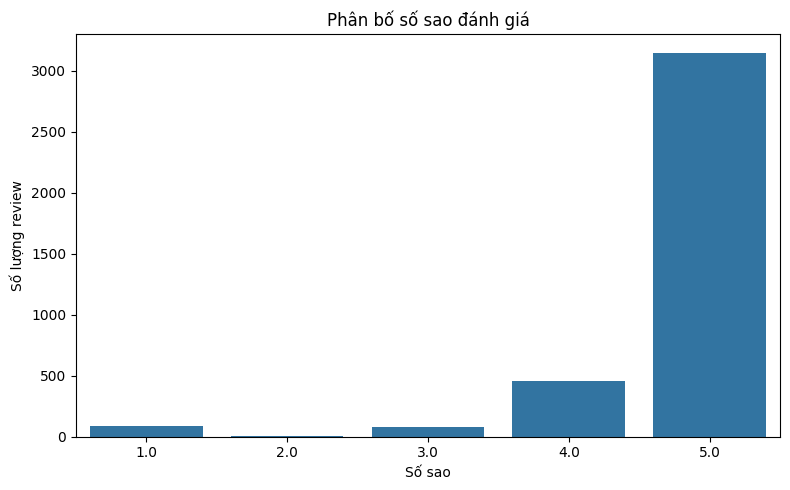

In [35]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="rating_star", color="#1f77b4")
plt.title("Phân bố số sao đánh giá")
plt.xlabel("Số sao")
plt.ylabel("Số lượng review")
plt.tight_layout()
plt.savefig("outputs/chart_rating_distribution.png", dpi=150)
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_11348\2219752114.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_time["month"] = df_time["created_at"].dt.to_period("M").astype(str)


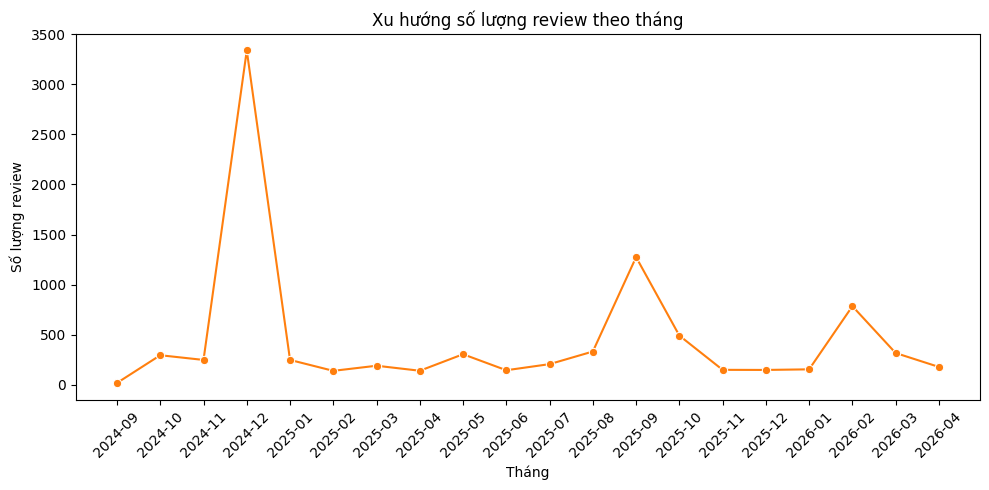

In [36]:
if df["created_at"].notna().any():
    df_time = df.dropna(subset=["created_at"]).copy()
    df_time["month"] = df_time["created_at"].dt.to_period("M").astype(str)
    monthly_count = df_time.groupby("month").size().reset_index(name="review_count")

    plt.figure(figsize=(10, 5))
    sns.lineplot(data=monthly_count, x="month", y="review_count", marker="o", color="#ff7f0e")
    plt.title("Xu hướng số lượng review theo tháng")
    plt.xlabel("Tháng")
    plt.ylabel("Số lượng review")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("outputs/chart_monthly_trend.png", dpi=150)
    plt.show()

    monthly_count.to_csv("outputs/table_monthly_trend.csv", index=False, encoding="utf-8-sig")
else:
    print("Không đủ dữ liệu thời gian để vẽ xu hướng theo tháng.")

In [37]:
stopwords_vi = {
    "và", "là", "của", "cho", "rất", "nhưng", "được", "mình", "shop", "sản", "phẩm",
    "này", "khi", "thì", "với", "có", "không", "đã", "trong", "hơi", "vẫn"
}

tokens = []
for text in df["comment_clean"]:
    words = [w for w in text.split() if len(w) >= 3 and w not in stopwords_vi]
    tokens.extend(words)

top_terms = pd.DataFrame(Counter(tokens).most_common(30), columns=["term", "frequency"])
display(top_terms.head(15))
top_terms.to_csv("outputs/table_top_terms.csv", index=False, encoding="utf-8-sig")

,term,frequency
0,máy,4139
1,hàng,1587
2,hình,1582
3,dùng,1310
4,tốt,1219
5,màn,1164
6,việc,1109
7,làm,1106
8,mua,1104
9,giá,1013


In [38]:
rating_table = df.groupby("rating_star").size().reset_index(name="review_count").sort_values("rating_star")
display(rating_table)
rating_table.to_csv("outputs/table_rating_distribution.csv", index=False, encoding="utf-8-sig")

clean_path = "data/cleaned_reviews.csv"
df.to_csv(clean_path, index=False, encoding="utf-8-sig")
print(f"Đã lưu dữ liệu sạch vào: {clean_path}")

,rating_star,review_count
0,1.0,86
1,2.0,10
2,3.0,83
3,4.0,454
4,5.0,3147


Đã lưu dữ liệu sạch vào: data/cleaned_reviews.csv
